In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,Relatively New,NaN,NaN,900.0,0,0,0,0,0,unfurnished,28,450.0
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,Old Property,NaN,NaN,650.0,0,0,0,0,0,semifurnished,37,325.0
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,New Property,NaN,NaN,595.0,0,0,0,0,0,unfurnished,36,297.5
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,Relatively New,NaN,NaN,1200.0,1,0,0,0,0,unfurnished,76,600.0
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,Under Construction,1345.0,NaN,NaN,1,0,0,0,0,unfurnished,0,672.5


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                  984
agePossession             0
super_built_up_area    1625
built_up_area          1949
carpet_area            1674
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

## bulit_up_area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

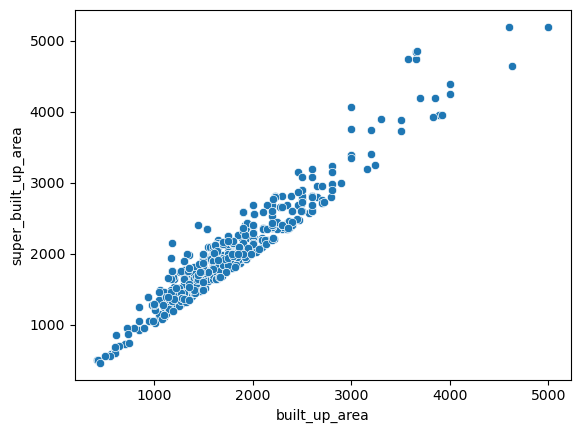

In [6]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

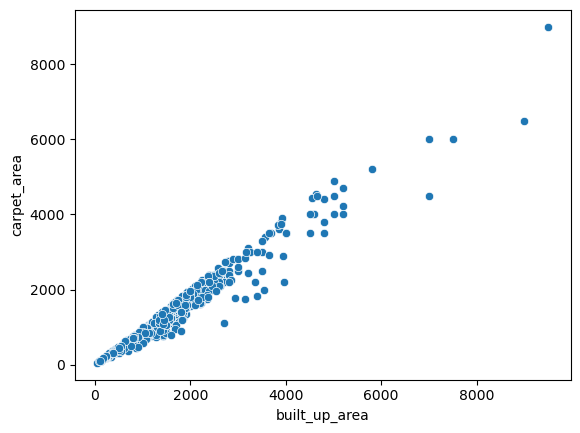

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [8]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

0

In [9]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [10]:
all_present_df.shape

(530, 24)

In [11]:
all_present_df.shape

(530, 24)

In [12]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [13]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [14]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1052289815447711 0.900140056022409


In [15]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [16]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
30,flat,bhawna cghs,sector 43,3.25,10156.0,3200.0,Super Built up area 3200(297.29 sq.m.)Carpet a...,4,4,3+,12.0,NaN,Moderately Old,3200.0,NaN,3000.0,0,0,0,1,0,semifurnished,119,800.000000
35,flat,chintels paradiso,sector 109,1.80,8867.0,2030.0,Super Built up area 2030(188.59 sq.m.)Carpet a...,3,3,2,0.0,East,Moderately Old,2030.0,NaN,1785.0,0,1,0,0,0,unfurnished,83,676.666667
36,flat,breez global hill view,sohna road,0.30,5405.0,555.0,Super Built up area 655(60.85 sq.m.)Carpet are...,2,2,2,6.0,North-East,New Property,655.0,NaN,555.0,0,0,0,0,0,unfurnished,109,277.500000
56,flat,silverglades the melia,sohna road,1.01,6999.0,1443.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,2,2,3,12.0,NaN,Relatively New,1450.0,NaN,950.0,1,0,0,0,0,unfurnished,80,721.500000
58,flat,umang winter hills,sector 77,0.99,7857.0,1260.0,Super Built up area 1260(117.06 sq.m.)Carpet a...,2,2,2,1.0,North,Relatively New,1260.0,NaN,1000.0,0,0,0,0,0,unfurnished,97,630.000000


In [17]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) +(sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\1533986712.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) +(sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\1533986712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                  984
agePossession             0
super_built_up_area    1625
built_up_area          1528
carpet_area            1674
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [20]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,Under Construction,1345.0,NaN,NaN,1,0,0,0,0,unfurnished,0,672.5
6,flat,the cocoon,dwarka expressway,2.00,13333.0,1500.0,Super Built up area 1500(139.35 sq.m.),3,3,3,5.0,NaN,New Property,1500.0,NaN,NaN,0,0,0,0,0,unfurnished,0,500.0
13,flat,godrej,sector 33,0.95,6859.0,1385.0,Super Built up area 1385(128.67 sq.m.),2,2,3+,3.0,South-East,Under Construction,1385.0,NaN,NaN,0,0,0,0,0,unfurnished,0,692.5
14,flat,shree vardhman flora,sector 90,0.70,5385.0,1300.0,Super Built up area 1300(120.77 sq.m.),2,2,3,13.0,NaN,New Property,1300.0,NaN,NaN,1,0,0,0,0,unfurnished,15,650.0
18,flat,central park flower valley,sector 33,2.20,10476.0,2100.0,Super Built up area 2100(195.1 sq.m.),3,3,3,12.0,North-East,New Property,2100.0,NaN,NaN,0,1,0,0,0,semifurnished,49,700.0


In [22]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round

In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                  984
agePossession             0
super_built_up_area    1625
built_up_area           658
carpet_area            1674
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [25]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,Relatively New,NaN,NaN,900.0,0,0,0,0,0,unfurnished,28,450.000000
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,Old Property,NaN,NaN,650.0,0,0,0,0,0,semifurnished,37,325.000000
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,New Property,NaN,NaN,595.0,0,0,0,0,0,unfurnished,36,297.500000
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,Relatively New,NaN,NaN,1200.0,1,0,0,0,0,unfurnished,76,600.000000
7,flat,ats triumph,sector 104,1.80,7860.0,2290.0,Carpet area: 2290 (212.75 sq.m.),3,4,3,14.0,NaN,New Property,NaN,NaN,2290.0,0,0,0,0,0,unfurnished,60,763.333333


In [27]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet

In [28]:
df.update(c_df)

In [29]:


df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                  984
agePossession             0
super_built_up_area    1625
built_up_area             0
carpet_area            1674
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

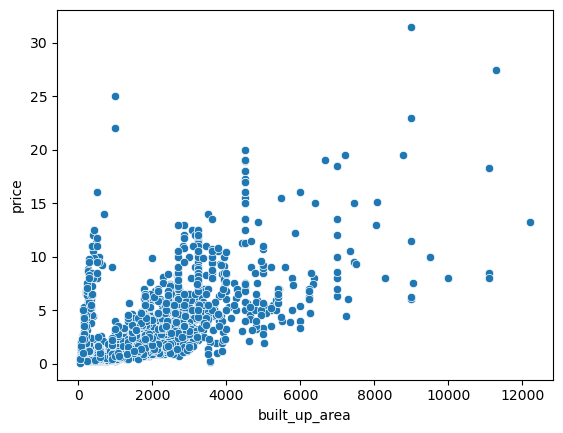

In [30]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [31]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [32]:
anamoly_df.sample(5)

,price,area,built_up_area
2037,3.30,2150.0,1640.0
3341,3.49,1728.0,1728.0
3428,4.50,1350.0,1350.0
1362,2.70,2576.0,1891.0
3385,7.10,2259.0,240.0


In [33]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [34]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

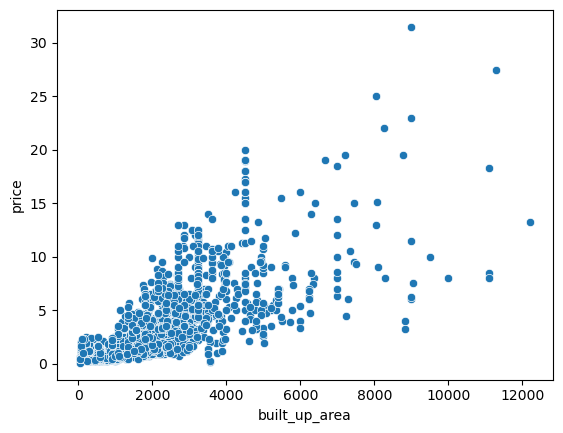

In [35]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [36]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [37]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2,2,1,4.0,West,Relatively New,1000.0,0,0,0,0,0,unfurnished,28
1,flat,apna enclave,sector 3,0.50,7692.0,2,2,1,1.0,West,Old Property,722.0,0,0,0,0,0,semifurnished,37
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,2,2,3,12.0,NaN,New Property,661.0,0,0,0,0,0,unfurnished,36
3,flat,smart world orchard,sector 61,1.47,12250.0,2,2,2,2.0,NaN,Relatively New,1333.0,1,0,0,0,0,unfurnished,76
4,flat,parkwood westend,sector 92,0.70,5204.0,2,2,3,5.0,NaN,Under Construction,1217.0,1,0,0,0,0,unfurnished,0


In [38]:
df.shape

(3494, 19)

In [39]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum            17
facing             984
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

## floorNum

In [40]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
167,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,unfurnished,0
2557,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,unfurnished,0
2800,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,unfurnished,88
2819,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,unfurnished,0
2888,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,unfurnished,9
2916,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,unfurnished,0
2928,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,unfurnished,0
2973,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,unfurnished,0
2986,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,unfurnished,0
3100,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,unfurnished,0


In [41]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [42]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_3384\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [43]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing             984
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

## facing

<Axes: ylabel='count'>

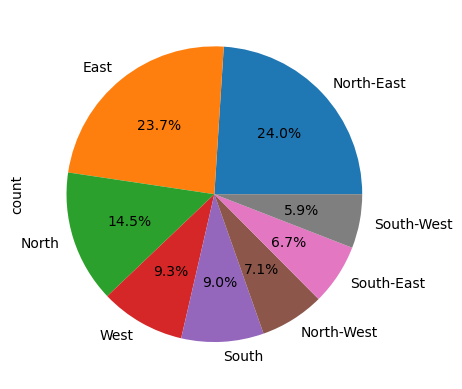

In [44]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [45]:
df.drop(columns=['facing'],inplace=True)

In [46]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2799,house,independent,sector 48,8.40,25926.0,4,4,3,2.0,Old Property,3240.0,0,1,0,1,0,semifurnished,15
3088,house,vatika india next,sector 82,6.50,20062.0,4,3,0,2.0,Undefined,3240.0,0,0,0,0,0,unfurnished,0
2635,flat,my home,sector 110,0.22,4400.0,2,2,1,1.0,New Property,556.0,0,0,0,0,0,semifurnished,0
3082,house,bhim nagar society,sector 6,0.40,2500.0,4,2,2,1.0,Undefined,1600.0,0,0,0,0,0,unfurnished,0
2400,flat,sare green parc phase 3,sector 92,0.95,4857.0,4,3,3,4.0,Moderately Old,1770.0,0,0,0,0,0,unfurnished,67


In [47]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [48]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2557,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,unfurnished,0


In [49]:
df.drop(index=[2557],inplace=True)

In [50]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

## agePossession

In [51]:
df['agePossession'].value_counts()

agePossession
Relatively New        1692
New Property           573
Moderately Old         538
Old Property           282
Undefined              280
Under Construction     128
Name: count, dtype: int64

In [52]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,flat,signature global infinity mall,sector 36,0.41,6269.0,2,2,3,3.0,Undefined,654.0,0,0,0,0,0,unfurnished,0
15,flat,sobha city,sector 108,3.95,16859.0,4,5,3,25.0,Undefined,2343.0,0,0,0,0,0,unfurnished,59
16,flat,senate court,sector 62,0.90,14085.0,1,1,0,0.0,Undefined,639.0,0,0,0,0,0,unfurnished,0
24,flat,the serenas,sector 36,0.42,7910.0,2,2,1,3.0,Undefined,590.0,0,0,0,0,0,unfurnished,0
25,flat,m3m golfestate,sector 65,6.15,18331.0,3,4,2,20.0,Undefined,3355.0,0,0,0,0,0,unfurnished,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,house,independent,sector 108,1.34,5000.0,1,1,0,1.0,Undefined,2680.0,0,0,0,0,0,unfurnished,0
3151,house,independent,sector 39,0.34,7556.0,1,1,1,1.0,Undefined,450.0,0,0,0,0,0,unfurnished,0
3152,house,independent,sector 105,9.90,49500.0,2,2,2,3.0,Undefined,2000.0,0,0,0,0,0,unfurnished,0
3153,house,independent,sector 43,2.15,13030.0,1,1,0,1.0,Undefined,1650.0,0,0,0,0,0,unfurnished,0


In [53]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [54]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [55]:
df['agePossession'].value_counts()

agePossession
Relatively New        1814
New Property           612
Moderately Old         576
Old Property           312
Under Construction     132
Undefined               47
Name: count, dtype: int64

In [56]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [57]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [58]:
df['agePossession'].value_counts()

agePossession
Relatively New        1820
New Property           612
Moderately Old         580
Old Property           315
Under Construction     132
Undefined               34
Name: count, dtype: int64

In [59]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1822
New Property           612
Moderately Old         612
Old Property           315
Under Construction     132
Name: count, dtype: int64

In [62]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [63]:
df.to_csv('Gurgaon_properties_missing_value_imputation.csv',index=False)

In [64]:
df.shape

(3493, 18)

In [81]:
df=pd.read_csv('Gurgaon_properties_missing_value_imputation.csv')

In [82]:
df[df['built_up_area'] < 100]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
29,flat,ompee k s residency,sector 110,1.60,2993.0,2,2,2,1.0,Relatively New,73.0,0,0,0,0,0,unfurnished,0
100,flat,godrej aria,sector 79,1.10,11482.0,2,2,3,9.0,New Property,81.0,0,0,0,0,0,unfurnished,62
280,flat,godrej air,sector 85,1.05,10606.0,2,2,1,15.0,Relatively New,97.0,0,0,0,0,0,unfurnished,45
1877,flat,godrej nature plus,sector 33,1.31,15976.0,2,2,2,4.0,Under Construction,85.0,0,0,0,0,0,unfurnished,92
2002,flat,godrej nature plus,sector 33,1.20,14371.0,2,2,3,1.0,New Property,86.0,0,0,0,0,0,unfurnished,65
2038,flat,housing board colony,sector 51,0.30,4630.0,1,1,0,0.0,Moderately Old,80.0,1,0,0,0,0,unfurnished,15
2204,flat,godrej,sector 79,1.47,16261.0,2,2,3,9.0,New Property,93.0,1,0,0,0,0,unfurnished,99
2213,flat,godrej nature plus,sector 33,1.20,13363.0,2,2,0,11.0,Under Construction,85.0,0,0,0,0,0,unfurnished,56
2461,flat,godrej summit,sector 104,0.82,9856.0,2,2,3,12.0,Relatively New,86.0,1,0,0,0,0,unfurnished,120
2571,flat,godrej nature plus,sector 33,1.08,13123.0,2,2,3,8.0,Relatively New,85.0,0,0,0,0,0,unfurnished,56


In [84]:
df[df['built_up_area'] < 100].shape

(26, 18)